# zedstat example notebook

This notebook is a full, heavily commented walkthrough of the current `zedstat.py` workflow.

It covers:

- loading data and checking the active `zedstat.py` interface
- computing the empirical ROC table
- smoothing with or without convexification
- computing threshold-based measures and analytic bounds
- plotting ROC, PRC, and LR-space curves with low-opacity confidence envelopes
- extracting operating points
- mapping score to **threshold PPV**
- fitting **calibrated score-to-probability** mappings with tunable calibration parameters
- plotting the calibration curve with a user-chosen number of bins
- computing analytic and optional bootstrap AUC
- estimating the required number of samples as a function of target AUC precision
- plotting required sample size versus allowed AUC deviation
- generating an interpretation table at a chosen false-positive rate

The notebook is written to be robust to small interface differences across nearby `zedstat.py` revisions by checking signatures when needed.

## 1. User parameters

Edit only this cell first. Everything else should run from these settings.

In [33]:
from pathlib import Path

# ------------------------------------------------------------------
# FILE / COLUMN SETTINGS
# ------------------------------------------------------------------
data_path = Path("./PREDICTIONS_NATIONAL_SAMPLE.parquet")   # change to your file
data_path = Path("./SUICIDALITY-F25504W6WS.parquet")   # change to your file
read_method = "parquet"                 # one of: 'parquet', 'csv'
score_col = "predicted_risk"
label_col = "target"

# ------------------------------------------------------------------
# PROBLEM SETTINGS
# ------------------------------------------------------------------
deployment_prevalence = 0.10            # prevalence to use for PPV / NPV style measures
lower_score_is_risk = False             # set True only if smaller score = higher risk

# ------------------------------------------------------------------
# ROC / MEASURE SETTINGS
# ------------------------------------------------------------------
use_convexify = False                   # True => use ROC upper hull before interpolation
smooth_step = 0.001                     # FPR grid spacing for smooth()
precision = 3                           # decimal precision for usample()
alpha = 0.05                            # confidence level parameter
lr_fpr_floor = 0.001                    # censor LR+ / LR- when FPR is below this

# ------------------------------------------------------------------
# CALIBRATION SETTINGS
# ------------------------------------------------------------------
calibration_n_bins = 100                 # number of bins in calibration plot/table
calibration_n_splits = 5                # CV folds for out-of-fold isotonic calibration
random_state = 4

# ------------------------------------------------------------------
# THRESHOLD / INTERPRETATION SETTINGS
# ------------------------------------------------------------------
example_scores = [0.02, 0.05, 0.10]     # example score values to query
interpret_fpr = 0.01                    # operating point for interpret()
interpret_positive_cases = 100
five_yr_survival = None                 # set numeric value if you want NNS
factor = 1.0

# ------------------------------------------------------------------
# SAMPLE SIZE / AUC PLANNING SETTINGS
# ------------------------------------------------------------------
delta_auc_grid = [0.20, 0.15, 0.10, 0.08, 0.06, 0.05, 0.04, 0.03, 0.02, 0.01]
target_auc_for_planning = None          # None => use nominal AUC estimated from current data

# ------------------------------------------------------------------
# BOOTSTRAP AUC SETTINGS
# ------------------------------------------------------------------
run_bootstrap_auc = True
bootstrap_n = 1000                      # increase for final reporting
bootstrap_stratified = True

## 2. Imports and module sanity check

This cell prints the active file path and the signatures of the main entry points.  
That is useful because several earlier copies of `zedstat.py` in this thread had slightly different interfaces.

In [34]:
import inspect
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import zedstat
importlib.reload(zedstat)

print("Active zedstat.py:", zedstat.__file__)
print("processRoc.__init__ signature:")
print(inspect.signature(zedstat.processRoc.__init__))
print()
print("pipeline signature:")
print(inspect.signature(zedstat.pipeline))

Active zedstat.py: /home/ishanu/Dropbox/ZED/Research/testbed/zedstat.py
processRoc.__init__ signature:
(self, df=None, fprcol='fpr', tprcol='tpr', thresholdcol='threshold', prevalence=None, order=2, total_samples=None, positive_samples=None, alpha=0.05, lr_fpr_floor=0.001)

pipeline signature:
(df, risk='predicted_risk', target='target', steps=1000, TARGET=[1], order=3, alpha=0.05, prevalence=0.002, precision=3, convexify=False, lr_fpr_floor=0.001, outfile=None)


## 3. Load the data

This notebook supports parquet and CSV for convenience.

In [35]:
if read_method == "parquet":
    df = pd.read_parquet(data_path)
elif read_method == "csv":
    df = pd.read_csv(data_path)
else:
    raise ValueError("read_method must be 'parquet' or 'csv'")

print(df.shape)
display(df.head())

if score_col not in df.columns:
    raise KeyError(f"Missing score column: {score_col}")

if label_col not in df.columns:
    raise KeyError(f"Missing label column: {label_col}")

print("Columns OK.")

(1190695, 10)


,patient_id,age_at_screening,PRESENCE_DX_score,PRESENCE_RX_score,PRESENCE_PROC_score,ODDSRATIO_DX_score,ODDSRATIO_RX_score,ODDSRATIO_PROC_score,predicted_risk,target
0,33437470002,40.0,0.073964,0.053557,0.090704,0.024461,0.035916,0.072240,0.018509,0
1,33460332101,28.0,0.017916,0.006123,0.029101,0.015219,0.007483,0.025620,0.007422,0
2,3340692401,36.0,0.003783,0.005580,0.005544,0.004515,0.006397,0.005047,0.005033,0
3,33421686002,44.0,0.003832,0.004999,0.003765,0.008421,0.007085,0.003657,0.005182,0
4,33416141602,30.0,0.003260,0.003607,0.006052,0.004513,0.004139,0.005485,0.005020,0


Columns OK.


## 4. Compute the empirical ROC table

`genroc(...)` creates the empirical threshold/FPR/TPR table directly from raw scores and labels.

In [36]:
rf, total_samples, positive_samples = zedstat.genroc(
    df,
    risk=score_col,
    target=label_col,
)

print("total_samples =", total_samples)
print("positive_samples =", positive_samples)
display(rf.head())

total_samples = 1190695
positive_samples = 7554


,threshold,fpr,tpr
0,0.181449,0.000000e+00,0.000132
1,0.179652,0.000000e+00,0.000265
2,0.179503,0.000000e+00,0.000397
3,0.178460,0.000000e+00,0.000530
4,0.177715,8.452078e-07,0.000530


## 5. Build the main `processRoc` object

This block is written to handle both cases:
- newer `zedstat.py` versions where `lr_fpr_floor` is accepted directly in the constructor
- older nearby variants where it is set later with `set_lr_fpr_floor(...)`

In [37]:
proc_sig = inspect.signature(zedstat.processRoc.__init__)

proc_kwargs = dict(
    df=rf,
    prevalence=deployment_prevalence,
    total_samples=total_samples,
    positive_samples=positive_samples,
    alpha=alpha,
)

if "lr_fpr_floor" in proc_sig.parameters:
    proc_kwargs["lr_fpr_floor"] = lr_fpr_floor

zt = zedstat.processRoc(**proc_kwargs)

if hasattr(zt, "set_lr_fpr_floor"):
    zt.set_lr_fpr_floor(lr_fpr_floor)
elif not hasattr(zt, "lr_fpr_floor"):
    # This fallback keeps the notebook usable even if a nearby version
    # stores the threshold as a plain attribute.
    zt.lr_fpr_floor = lr_fpr_floor

print("processRoc object created.")

processRoc object created.


## 6. Smooth the ROC, compute threshold-based measures, and derive analytic bounds

Important notes:

- `convexify=False` means you keep the empirical ROC shape and only interpolate it.
- `convexify=True` means you replace the empirical ROC by its upper hull before interpolation.
- There is only one set of measures in the downstream tables. Convexification is just a preprocessing choice.
- Likelihood ratios are censored when `FPR < lr_fpr_floor`.

In [38]:
zt.smooth(STEP=smooth_step, convexify=use_convexify)
zt.allmeasures(prevalence=deployment_prevalence, interpolate=True)
zt.usample(precision=precision)
zt.getBounds()

perf_df = (
    zt.get()
    .join(zt.df_lim["U"], rsuffix="_upper")
    .join(zt.df_lim["L"], rsuffix="_lower")
)

display(perf_df.head())
print(perf_df.columns.tolist())

,tpr,ppv,acc,npv,LR+,LR-,threshold,tpr_upper,ppv_upper,acc_upper,...,LR+_upper,LR-_upper,threshold_upper,tpr_lower,ppv_lower,acc_lower,npv_lower,LR+_lower,LR-_lower,threshold_lower
fpr,,,,,,,,,,,,,,,,,,,,,
0.000,0.000530,1.000000,0.900053,0.900048,NaN,NaN,0.178460,0.001361,1.000000,0.900136,...,NaN,NaN,0.178460,0.000206,0.886184,0.900018,0.900122,NaN,NaN,0.178460
0.001,0.070426,0.886687,0.906143,0.906298,70.426264,0.930504,0.074554,0.076417,0.899883,0.906792,...,80.834788,0.936120,0.074554,0.064872,0.871943,0.905534,0.906851,61.238031,0.924457,0.074554
0.002,0.109119,0.858400,0.909112,0.909765,54.559306,0.892667,0.057011,0.116349,0.870638,0.909906,...,60.563969,0.899588,0.057011,0.102285,0.845156,0.908355,0.910438,49.125152,0.885352,0.057011
0.003,0.138337,0.836697,0.911134,0.912385,46.112435,0.864255,0.047877,0.146307,0.848544,0.912018,...,50.397611,0.871968,0.047877,0.130735,0.824153,0.910283,0.913133,42.170310,0.856179,0.047877
0.004,0.166667,0.822368,0.913067,0.914943,41.666667,0.836680,0.041784,0.175240,0.833596,0.914025,...,45.073527,0.845045,0.041784,0.158432,0.810561,0.912139,0.915753,38.497861,0.827979,0.041784


['tpr', 'ppv', 'acc', 'npv', 'LR+', 'LR-', 'threshold', 'tpr_upper', 'ppv_upper', 'acc_upper', 'npv_upper', 'LR+_upper', 'LR-_upper', 'threshold_upper', 'tpr_lower', 'ppv_lower', 'acc_lower', 'npv_lower', 'LR+_lower', 'LR-_lower', 'threshold_lower']


## 7. Quick look at the resulting performance table

The combined `perf_df` contains the nominal threshold-level measures and their upper/lower analytic bounds.

In [39]:
summary_cols = [c for c in ["threshold", "tpr", "ppv", "npv", "LR+", "LR-", "tpr_upper", "ppv_upper", "tpr_lower", "ppv_lower"] if c in perf_df.columns]
display(perf_df[summary_cols].head(10))

,threshold,tpr,ppv,npv,LR+,LR-,tpr_upper,ppv_upper,tpr_lower,ppv_lower
fpr,,,,,,,,,,
0.000,0.178460,0.000530,1.000000,0.900048,NaN,NaN,0.001361,1.000000,0.000206,0.886184
0.001,0.074554,0.070426,0.886687,0.906298,70.426264,0.930504,0.076417,0.899883,0.064872,0.871943
0.002,0.057011,0.109119,0.858400,0.909765,54.559306,0.892667,0.116349,0.870638,0.102285,0.845156
0.003,0.047877,0.138337,0.836697,0.912385,46.112435,0.864255,0.146307,0.848544,0.130735,0.824153
0.004,0.041784,0.166667,0.822368,0.914943,41.666667,0.836680,0.175240,0.833596,0.158432,0.810561
0.005,0.037561,0.186788,0.805857,0.916749,37.357691,0.817298,0.195736,0.816906,0.178160,0.794235
0.006,0.034121,0.204527,0.791125,0.918342,34.087900,0.800274,0.213772,0.801974,0.195583,0.779585
0.007,0.031460,0.221472,0.778537,0.919868,31.638867,0.784016,0.230976,0.789289,0.212251,0.767309
0.008,0.029376,0.236034,0.766259,0.921175,29.504236,0.770127,0.245743,0.776899,0.226594,0.755179


## 8. Plot ROC, PRC, and LR-space curves with filled bounds

The ROC panel uses the nominal FPR grid directly.  
The PRC and LR panels are drawn as low-opacity polygons between lower and upper curves.

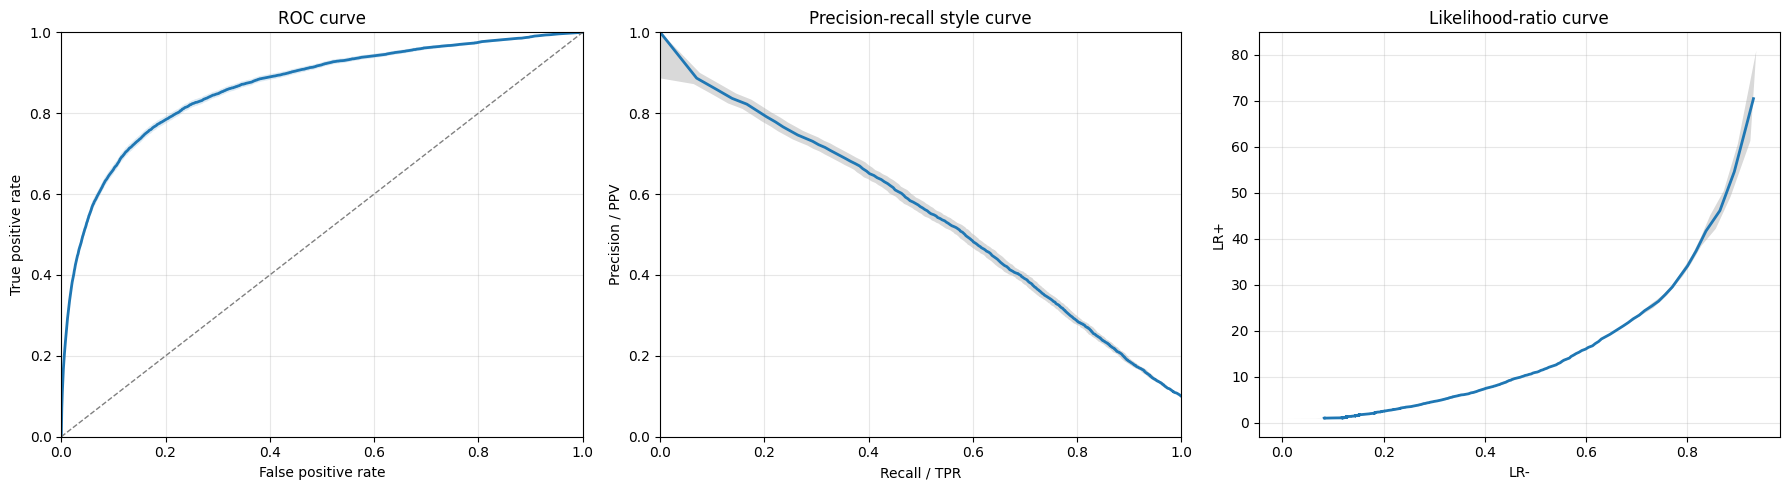

In [40]:
def _as_plot_df(perf_df):
    pf = perf_df.reset_index().copy()
    if "fpr" not in pf.columns:
        pf = pf.rename(columns={pf.columns[0]: "fpr"})
    return pf

def _fill_between_curves(ax, x1, y1, x2, y2, color="k", alpha=0.12, zorder=1):
    x1 = np.asarray(x1, dtype=float)
    y1 = np.asarray(y1, dtype=float)
    x2 = np.asarray(x2, dtype=float)
    y2 = np.asarray(y2, dtype=float)

    m1 = np.isfinite(x1) & np.isfinite(y1)
    m2 = np.isfinite(x2) & np.isfinite(y2)

    x1, y1 = x1[m1], y1[m1]
    x2, y2 = x2[m2], y2[m2]

    if len(x1) < 2 or len(x2) < 2:
        return

    o1 = np.argsort(x1)
    o2 = np.argsort(x2)

    x1, y1 = x1[o1], y1[o1]
    x2, y2 = x2[o2], y2[o2]

    poly_x = np.r_[x1, x2[::-1]]
    poly_y = np.r_[y1, y2[::-1]]
    ax.fill(poly_x, poly_y, color=color, alpha=alpha, linewidth=0, zorder=zorder)

pf = _as_plot_df(perf_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -------------------------
# ROC: FPR vs TPR
# -------------------------
roc = pf[["fpr", "tpr", "tpr_lower", "tpr_upper"]].copy().sort_values("fpr")
axes[0].fill_between(roc["fpr"], roc["tpr_lower"], roc["tpr_upper"], alpha=0.15)
axes[0].plot(roc["fpr"], roc["tpr"], lw=2)
axes[0].plot([0, 1], [0, 1], "--", color="0.5", lw=1)
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)

# -------------------------
# PRC: Recall (=TPR) vs Precision (=PPV)
# -------------------------
pr = pf[["tpr", "ppv", "tpr_lower", "ppv_lower", "tpr_upper", "ppv_upper"]].copy()
_fill_between_curves(
    axes[1],
    pr["tpr_lower"], pr["ppv_lower"],
    pr["tpr_upper"], pr["ppv_upper"],
    alpha=0.15,
)
pr_nom = pr[["tpr", "ppv"]].replace([np.inf, -np.inf], np.nan).dropna().sort_values("tpr")
axes[1].plot(pr_nom["tpr"], pr_nom["ppv"], lw=2)
axes[1].set_xlabel("Recall / TPR")
axes[1].set_ylabel("Precision / PPV")
axes[1].set_title("Precision-recall style curve")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)

# -------------------------
# LR-space: LR- vs LR+
# -------------------------
lr = pf[["LR-", "LR+", "LR-_lower", "LR+_lower", "LR-_upper", "LR+_upper"]].copy()
lr = lr.replace([np.inf, -np.inf], np.nan)

_fill_between_curves(
    axes[2],
    lr["LR-_lower"], lr["LR+_lower"],
    lr["LR-_upper"], lr["LR+_upper"],
    alpha=0.15,
)
lr_nom = lr[["LR-", "LR+"]].dropna()
lr_nom = lr_nom[(lr_nom["LR-"] > 0) & (lr_nom["LR+"] > 0)].sort_values("LR-")
axes[2].plot(lr_nom["LR-"], lr_nom["LR+"], lw=2)
axes[2].set_xlabel("LR-")
axes[2].set_ylabel("LR+")
axes[2].set_title("Likelihood-ratio curve")
axes[2].grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()

## 9. Query threshold-level PPV at selected scores

This is **not** patient-level calibrated probability.  
It is the PPV associated with the threshold equal to that score.

In [41]:
threshold_ppv = zt.score_to_threshold_ppv(
    example_scores,
    regen=False,   # use the performance table already built above
)

threshold_ppv_df = pd.DataFrame({
    "score": example_scores,
    "threshold_ppv": np.asarray(threshold_ppv, dtype=float),
})

display(threshold_ppv_df)

,score,threshold_ppv
0,0.02,0.702557
1,0.05,0.841741
2,0.10,0.914437


## 10. Fit calibrated score-to-probability mapping

This is the patient-level calibration path based on out-of-fold isotonic regression.

The two most important user-tunable parameters here are:

- `calibration_n_splits`
- `calibration_n_bins`

The first affects cross-fitted calibration. The second affects only the displayed calibration curve aggregation.

In [42]:
if not hasattr(zt, "fit_score_calibration"):
    raise AttributeError("This zedstat.py does not expose fit_score_calibration(...).")

zt.fit_score_calibration(
    df,
    score_col=score_col,
    label_col=label_col,
    target_prevalence=deployment_prevalence,
    lower_score_is_risk=lower_score_is_risk,
    n_splits=calibration_n_splits,
    random_state=random_state,
    n_bins=calibration_n_bins,
)

cal_df = zt.calibration_curve()
display(cal_df)

,bin,n,cases_unweighted,mean_pred,obs_rate,prob_min,prob_max
0,0,11907,8,0.008390,0.011565,0.008390,0.008421
1,1,11907,8,0.008421,0.011565,0.008421,0.008425
2,2,11907,8,0.008448,0.011565,0.008425,0.009139
3,3,11907,6,0.009214,0.008697,0.009139,0.010897
4,4,11907,8,0.010930,0.011565,0.010897,0.010956
...,...,...,...,...,...,...,...
95,95,11907,330,0.329000,0.331578,0.317996,0.346059
96,96,11907,370,0.368806,0.358200,0.346059,0.414180
97,97,11907,533,0.451700,0.449192,0.414180,0.505549
98,98,11907,850,0.570439,0.572252,0.505549,0.617511


## 11. Plot the calibration curve

This plot uses the binned calibration table returned by `calibration_curve()`.  
The number of bins is controlled by `calibration_n_bins`.

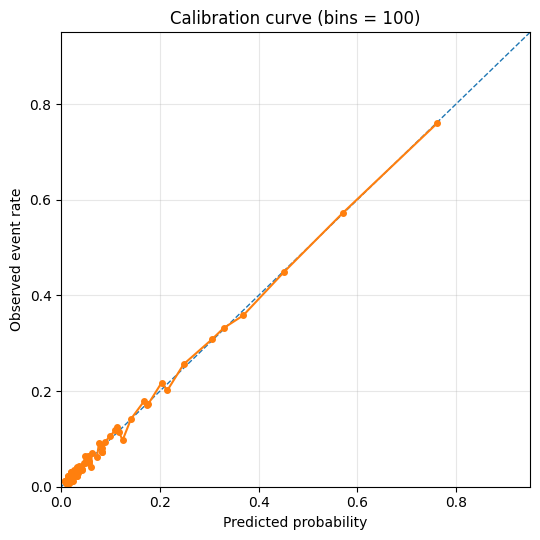

In [43]:
#plot_max = float(max(cal_df["mean_pred"].max(), cal_df["obs_rate"].max()))
#lim = nice_axis_limit(plot_max)
lim=.95
plt.figure(figsize=(5.5, 5.5))
plt.plot([0, lim], [0, lim], "--", linewidth=1)
plt.plot(cal_df["mean_pred"], cal_df["obs_rate"], marker="o", linewidth=1.5, markersize=4)
plt.xlabel("Predicted probability")
plt.ylabel("Observed event rate")
plt.title(f"Calibration curve (bins = {calibration_n_bins})")
plt.xlim(0, lim)
plt.ylim(0, lim)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Query calibrated patient-level probability at selected scores

This is the proper score-to-risk mapping after isotonic calibration.  
It is distinct from threshold PPV.

In [44]:
calibrated_probs = zt.scoretoprobability(example_scores)

calibrated_df = pd.DataFrame({
    "score": example_scores,
    "calibrated_probability": np.asarray(calibrated_probs, dtype=float),
})

display(calibrated_df)

,score,calibrated_probability
0,0.02,0.547208
1,0.05,0.767718
2,0.10,0.882976


## 13. Analytic AUC and optional bootstrap AUC

The analytic AUC uses the built-in closed-form approximation.  
The bootstrap AUC, when enabled, resamples raw score/label pairs and is often the more defensible reporting number.

In [45]:
auc_nominal, auc_upper, auc_lower = zt.auc()
print("Analytic AUC")
print("nominal =", auc_nominal)
print("upper   =", auc_upper)
print("lower   =", auc_lower)

Analytic AUC
nominal = 0.8648800549356397
upper   = 0.8701342414406549
lower   = 0.8596258684306245


In [46]:
if run_bootstrap_auc:
    auc_nominal_b, auc_upper_b, auc_lower_b = zt.auc(
        bootstrap=True,
        n_boot=bootstrap_n,
        random_state=random_state,
        stratified=bootstrap_stratified,
    )
    print()
    print("Bootstrap AUC")
    print("nominal =", auc_nominal_b)
    print("upper   =", auc_upper_b)
    print("lower   =", auc_lower_b)


Bootstrap AUC
nominal = 0.8648825129708062
upper   = 0.8695205147411965
lower   = 0.8602027104383825


## 14. Operating-zone extraction

This identifies operating points that simultaneously satisfy:
- `LR+ > LRplus`
- `LR- < LRminus`

and then reports one high-precision and one high-sensitivity endpoint per requested `n`.

In [52]:
zt.operating_zone(n=1, LRplus=10, LRminus=0.6)
display(zt._operating_zone)

,fpr,tpr,ppv,acc,npv,LR+,LR-,threshold
high precision,0.026,0.416733,0.640405,0.918273,0.937614,16.028187,0.598837,0.015072
high sensitivity,0.055,0.553084,0.527710,0.905808,0.950076,10.056081,0.472926,0.010394


## 15. Interpretation at a chosen false-positive rate

This block converts a chosen operating point into expected flag counts, false alarms, and missed cases for a hypothetical number of positives.

In [53]:
rf_interpret, txt_interpret, resdf_interpret = zt.interpret(
    fpr=interpret_fpr,
    number_of_positives=interpret_positive_cases,
    five_yr_survival=five_yr_survival,
    factor=factor,
)

display(rf_interpret)
display(resdf_interpret)

for line in txt_interpret:
    print(line)

,pos,flags,tp,fp,fn,tn
numbers,100.0,35.0,26.0,9.0,74.0,891.0


,estimates
POS,100.00
TP,26.00
FP,9.00
NEG,900.00
FLAGS,35.00
FN,74.00
TN,891.00
NNS,NaN
FLAGGED_FRACTION,0.04


For every 100 positive instances
we raise 35 flags,
out of which 26 are true positives
9 are false alarms
74 cases are missed


## 16. Sample-size planning for AUC precision

`zt.samplesize(delta_auc=...)` estimates the required number of samples per class under the model's approximation.  
A smaller allowed AUC deviation requires more samples.

If `target_auc_for_planning` is left as `None`, the notebook uses the current nominal AUC.

In [54]:
planning_auc = auc_nominal if target_auc_for_planning is None else float(target_auc_for_planning)

sample_size_rows = []
for d in delta_auc_grid:
    req = zt.samplesize(delta_auc=d, target_auc=planning_auc, alpha=.05, prevalence=.1)
    sample_size_rows.append({
        "delta_auc": d,
        "required_samples": req,
    })

sample_size_df = pd.DataFrame(sample_size_rows).sort_values("delta_auc", ascending=False)
display(sample_size_df)

,delta_auc,required_samples
0,0.20,55.769867
1,0.15,97.446339
2,0.10,216.440095
3,0.08,336.900131
4,0.06,597.141211
5,0.05,858.865150
6,0.04,1340.672325
7,0.03,2381.610633
8,0.02,5355.716308
9,0.01,21415.880890


## 17. Plot required sample size versus allowed AUC deviation

The x-axis is the maximum tolerated AUC error.  
The y-axis is the required number of samples **per class** under the approximation used by `zedstat.samplesize(...)`.

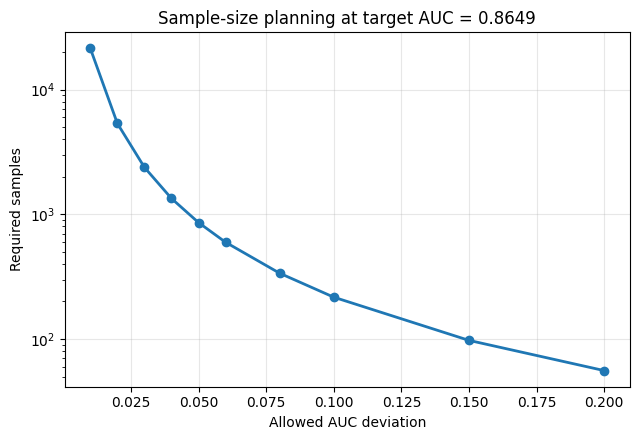

In [55]:
plt.figure(figsize=(6.5, 4.5))
plt.plot(sample_size_df["delta_auc"], sample_size_df["required_samples"], marker="o", linewidth=2)
plt.xlabel("Allowed AUC deviation")
plt.ylabel("Required samples")
plt.title(f"Sample-size planning at target AUC = {planning_auc:.4f}")
plt.grid(alpha=0.3)
plt.gca().set_yscale('log')
plt.tight_layout()
plt.show()

## 18. Optional direct `pipeline(...)` example

The `pipeline(...)` helper is convenient, but it exposes fewer intermediate objects than the manual path.  
Use the manual path above when you need fine-grained access to all features.

This block is guarded so it only passes parameters that the active `zedstat.py` version actually supports.

In [56]:
pipe_sig = inspect.signature(zedstat.pipeline)

pipe_kwargs = dict(
    df=df,
    risk=score_col,
    target=label_col,
    prevalence=deployment_prevalence,
    precision=precision,
)

if "convexify" in pipe_sig.parameters:
    pipe_kwargs["convexify"] = use_convexify
if "lr_fpr_floor" in pipe_sig.parameters:
    pipe_kwargs["lr_fpr_floor"] = lr_fpr_floor
if "alpha" in pipe_sig.parameters:
    pipe_kwargs["alpha"] = alpha

perf_df_pipeline, auc_pipeline = zedstat.pipeline(**pipe_kwargs)

print("pipeline AUC tuple:")
print(auc_pipeline)

display(perf_df_pipeline.head())

pipeline AUC tuple:
(0.8648800549356397, 0.8701342414406549, 0.8596258684306245)


,tpr,ppv,acc,npv,LR+,LR-,threshold,tpr_upper,ppv_upper,acc_upper,...,LR+_upper,LR-_upper,threshold_upper,tpr_lower,ppv_lower,acc_lower,npv_lower,LR+_lower,LR-_lower,threshold_lower
fpr,,,,,,,,,,,,,,,,,,,,,
0.000,0.000530,1.000000,0.900053,0.900048,NaN,NaN,0.178460,0.001361,1.000000,0.900136,...,NaN,NaN,0.178460,0.000206,0.886184,0.900018,0.900122,NaN,NaN,0.178460
0.001,0.070426,0.886687,0.906143,0.906298,70.426264,0.930504,0.074554,0.076417,0.899883,0.906792,...,80.834788,0.936120,0.074554,0.064872,0.871943,0.905534,0.906851,61.238031,0.924457,0.074554
0.002,0.109119,0.858400,0.909112,0.909765,54.559306,0.892667,0.057011,0.116349,0.870638,0.909906,...,60.563969,0.899588,0.057011,0.102285,0.845156,0.908355,0.910438,49.125152,0.885352,0.057011
0.003,0.138337,0.836697,0.911134,0.912385,46.112435,0.864255,0.047877,0.146307,0.848544,0.912018,...,50.397611,0.871968,0.047877,0.130735,0.824153,0.910283,0.913133,42.170310,0.856179,0.047877
0.004,0.166667,0.822368,0.913067,0.914943,41.666667,0.836680,0.041784,0.175240,0.833596,0.914025,...,45.073527,0.845045,0.041784,0.158432,0.810561,0.912139,0.915753,38.497861,0.827979,0.041784


## 19. Practical notes

- Use `score_to_threshold_ppv(...)` when you want **post-test yield at a threshold**.
- Use `fit_score_calibration(...)` followed by `scoretoprobability(...)` when you want **patient-level calibrated risk**.
- Use the manual `processRoc` path when you want complete control over convexification, LR censoring, calibration parameters, analytic bounds, and bootstrap AUC.
- Use `pipeline(...)` only for quick one-line summaries.